# Notebook 01 — Data Cleaning
### NER System | Sports & Political News
**Department of Software Engineering | SMIU**

This notebook loads the raw labeled Excel dataset, identifies issues, cleans the data, and saves a clean CSV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re, os, warnings
warnings.filterwarnings('ignore')
print('Libraries loaded OK')
print(f'Pandas: {pd.__version__}')

Libraries loaded OK
Pandas: 3.0.3


## Step 1 — Load Dataset

In [2]:
FILE_PATH = '../data/NER_Dataset_Complete_Tagged.xlsx'

df_sports   = pd.read_excel(FILE_PATH, sheet_name='Sports News')
df_politics = pd.read_excel(FILE_PATH, sheet_name='Political News')
df_raw = pd.concat([df_sports, df_politics], ignore_index=True)
df_raw.columns = ['article_id','domain','sentence','person_entities','location_entities']

print(f'Sports rows   : {len(df_sports)}')
print(f'Politics rows : {len(df_politics)}')
print(f'Total rows    : {len(df_raw)}')

Sports rows   : 1278
Politics rows : 507
Total rows    : 1785


In [3]:
df_raw.head(5)

,article_id,domain,sentence,person_entities,location_entities
0,1,Sports,Max Verstappen has threatened to quit Formula ...,Max Verstappen,NONE
1,1,Sports,Governing body the FIA said two weeks ago that...,NONE,NONE
2,1,Sports,But opposition has emerged in subsequent talks...,NONE,NONE
3,1,Sports,"""If it stays like this, it's going to be a lon...",Verstappen,NONE
4,1,Sports,"""It's just mentally not doable for me to stay ...",NONE,NONE


## Step 2 — Initial Inspection

In [4]:
print('=== NULL VALUES ===')
print(df_raw.isnull().sum())
print('\n=== DOMAIN DISTRIBUTION ===')
print(df_raw['domain'].value_counts())
print('\n=== DTYPES ===')
print(df_raw.dtypes)

=== NULL VALUES ===
article_id           0
domain               0
sentence             0
person_entities      0
location_entities    0
dtype: int64

=== DOMAIN DISTRIBUTION ===
domain
Sports      1278
Politics     507
Name: count, dtype: int64

=== DTYPES ===
article_id           int64
domain                 str
sentence               str
person_entities        str
location_entities      str
dtype: object


## Step 3 — Identify Issues

In [5]:
df_raw['word_count'] = df_raw['sentence'].fillna('').apply(lambda x: len(str(x).split()))

print('=== ISSUES BEFORE CLEANING ===')
print(f'Null sentences       : {df_raw["sentence"].isnull().sum()}')
print(f'Duplicate sentences  : {df_raw.duplicated(subset=["sentence"]).sum()}')
print(f'Short (<5 words)     : {len(df_raw[df_raw["word_count"] < 5])}')
noise = df_raw[~df_raw['sentence'].fillna('').str.contains(r'[a-zA-Z]', regex=True)]
print(f'Non-alphabetic rows  : {len(noise)}')

=== ISSUES BEFORE CLEANING ===
Null sentences       : 0
Duplicate sentences  : 19
Short (<5 words)     : 29
Non-alphabetic rows  : 0


## Step 4 — Clean Data

In [6]:
df = df_raw.copy()

# 1. Drop null sentences
before=len(df); df=df.dropna(subset=['sentence']); print(f'Remove nulls: {before-len(df)} removed')

# 2. Strip whitespace
for col in ['sentence','person_entities','location_entities','domain']:
    df[col] = df[col].fillna('NONE').astype(str).str.strip()

# 3. Fix encoding
def fix_enc(t):
    t=str(t)
    for k,v in {chr(8217):"'",chr(8216):"'",chr(8220):'"',chr(8221):'"',chr(8211):'-',chr(8212):'-',chr(160):' '}.items():
        t=t.replace(k,v)
    return re.sub(r'\s+',' ',t).strip()
df['sentence']=df['sentence'].apply(fix_enc)
df['person_entities']=df['person_entities'].apply(fix_enc)
df['location_entities']=df['location_entities'].apply(fix_enc)
print('Encoding fixed')

# 4. Remove non-alphabetic
before=len(df); df=df[df['sentence'].str.contains(r'[a-zA-Z]',regex=True)]; print(f'Remove non-alpha: {before-len(df)} removed')

# 5. Remove short sentences
df['word_count']=df['sentence'].apply(lambda x:len(str(x).split()))
before=len(df); df=df[df['word_count']>=5]; print(f'Remove short: {before-len(df)} removed')

# 6. Remove duplicates
before=len(df); df=df.drop_duplicates(subset=['sentence']); print(f'Remove duplicates: {before-len(df)} removed')

# 7. Standardize NONE
df['person_entities']=df['person_entities'].replace({'nan':'NONE','NaN':'NONE','':'NONE'})
df['location_entities']=df['location_entities'].replace({'nan':'NONE','NaN':'NONE','':'NONE'})

# 8. Standardize domain
df['domain']=df['domain'].str.strip().str.title()

# 9. Reset index
df=df.reset_index(drop=True)
print(f'\nFinal rows: {len(df)}')

Remove nulls: 0 removed
Encoding fixed
Remove non-alpha: 0 removed
Remove short: 29 removed
Remove duplicates: 19 removed

Final rows: 1737


## Step 5 — Add Helper Columns

In [7]:
df['has_person']   = df['person_entities'] != 'NONE'
df['has_location'] = df['location_entities'] != 'NONE'
df['has_entity']   = df['has_person'] | df['has_location']
df['word_count']   = df['sentence'].apply(lambda x: len(str(x).split()))
print('Helper columns added')
print(f'Has PERSON   : {df["has_person"].sum()}')
print(f'Has LOCATION : {df["has_location"].sum()}')
print(f'Has Entity   : {df["has_entity"].sum()}')
print(f'No Entity    : {(~df["has_entity"]).sum()}')

Helper columns added
Has PERSON   : 614
Has LOCATION : 504
Has Entity   : 879
No Entity    : 858


## Step 6 — Cleaning Summary

In [8]:
print('='*50)
print('DATA CLEANING SUMMARY')
print('='*50)
print(f'Rows before  : {len(df_raw)}')
print(f'Rows after   : {len(df)}')
print(f'Removed      : {len(df_raw)-len(df)}')
print(f'Retention    : {len(df)/len(df_raw)*100:.1f}%')
print('='*50)
print(df.groupby('domain')[['has_person','has_location','has_entity']].sum())

DATA CLEANING SUMMARY
Rows before  : 1785
Rows after   : 1737
Removed      : 48
Retention    : 97.3%
          has_person  has_location  has_entity
domain                                        
Politics         137           159         241
Sports           477           345         638


## Step 7 — Visualizations

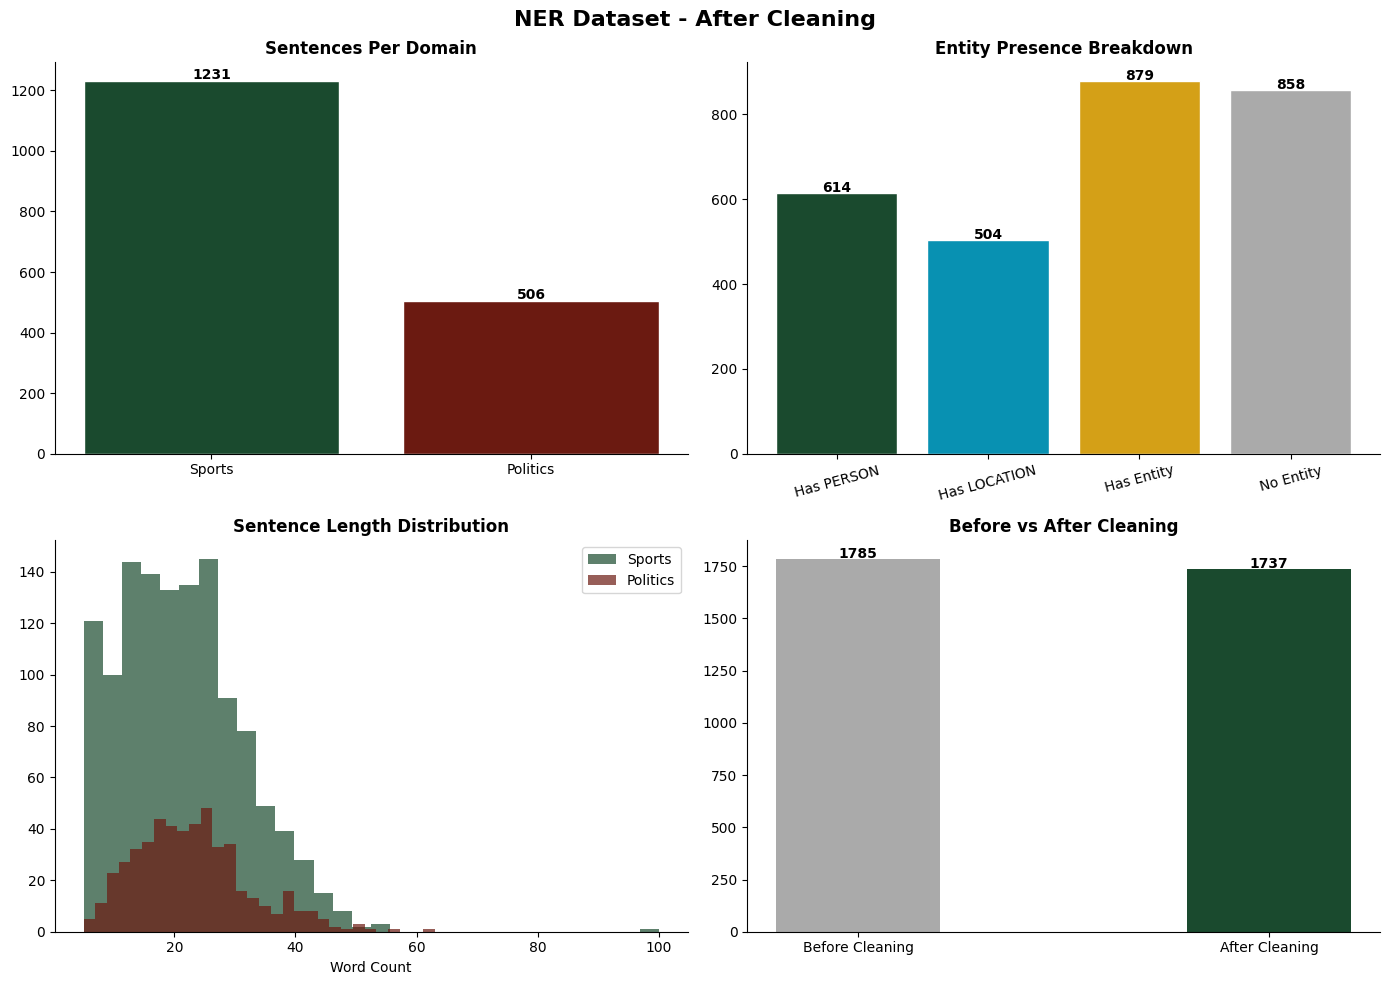

Charts saved


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NER Dataset - After Cleaning', fontsize=16, fontweight='bold')
GREEN,RED,TEAL,GOLD = '#1A4A2E','#6B1A11','#0891B2','#D4A017'

# Plot 1: Sentences per domain
dc = df['domain'].value_counts()
b1 = axes[0,0].bar(dc.index, dc.values, color=[GREEN,RED], edgecolor='white')
axes[0,0].set_title('Sentences Per Domain', fontweight='bold')
[axes[0,0].text(b.get_x()+b.get_width()/2, b.get_height()+5, str(v), ha='center', fontweight='bold') for b,v in zip(b1,dc.values)]
axes[0,0].spines['top'].set_visible(False); axes[0,0].spines['right'].set_visible(False)

# Plot 2: Entity breakdown
labs=['Has PERSON','Has LOCATION','Has Entity','No Entity']
vals=[df['has_person'].sum(),df['has_location'].sum(),df['has_entity'].sum(),(~df['has_entity']).sum()]
b2=axes[0,1].bar(labs, vals, color=[GREEN,TEAL,GOLD,'#AAA'], edgecolor='white')
axes[0,1].set_title('Entity Presence Breakdown', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=15)
[axes[0,1].text(b.get_x()+b.get_width()/2, b.get_height()+3, str(v), ha='center', fontweight='bold') for b,v in zip(b2,vals)]
axes[0,1].spines['top'].set_visible(False); axes[0,1].spines['right'].set_visible(False)

# Plot 3: Word count distribution
axes[1,0].hist(df[df['domain']=='Sports']['word_count'], bins=30, alpha=0.7, color=GREEN, label='Sports')
axes[1,0].hist(df[df['domain']=='Politics']['word_count'], bins=30, alpha=0.7, color=RED, label='Politics')
axes[1,0].set_title('Sentence Length Distribution', fontweight='bold')
axes[1,0].set_xlabel('Word Count'); axes[1,0].legend()
axes[1,0].spines['top'].set_visible(False); axes[1,0].spines['right'].set_visible(False)

# Plot 4: Before vs After
b4=axes[1,1].bar(['Before Cleaning','After Cleaning'],[len(df_raw),len(df)],color=['#AAA',GREEN],width=0.4)
axes[1,1].set_title('Before vs After Cleaning', fontweight='bold')
[axes[1,1].text(b.get_x()+b.get_width()/2, b.get_height()+5, str(v), ha='center', fontweight='bold') for b,v in zip(b4,[len(df_raw),len(df)])]
axes[1,1].spines['top'].set_visible(False); axes[1,1].spines['right'].set_visible(False)

plt.tight_layout()
os.makedirs('../data', exist_ok=True)
plt.savefig('../data/cleaning_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Charts saved')

## Step 8 — Save Cleaned Dataset

In [10]:
df_save = df[['article_id','domain','sentence','person_entities','location_entities',
              'has_person','has_location','has_entity','word_count']]

df_save.to_csv('../data/cleaned_data.csv', index=False, encoding='utf-8')
print(f'Saved: ../data/cleaned_data.csv')
print(f'Total rows: {len(df_save)}')

# Verify
df_v = pd.read_csv('../data/cleaned_data.csv')
print(f'Verified: {len(df_v)} rows loaded back OK')

Saved: ../data/cleaned_data.csv
Total rows: 1737
Verified: 1737 rows loaded back OK


---
## Notebook 01 Complete ✅
**Next → Notebook 02: EDA**